# EDA & Tiền xử lý — Obesity (`ObesityDataSet.csv`)

Bài toán **hồi quy**: dự đoán **cân nặng `Weight` (kg)** từ các đặc trưng nhân trắc học, thói quen
ăn uống và lối sống. Biến `NObeyesdad` (mức béo phì, 7 lớp có thứ tự) — vốn là nhãn phân loại của
bộ gốc — nay được dùng làm **feature** (ordinal 0..6). Mỗi bước gồm **Lý do** và **Phân tích**
(số liệu lấy từ output thật khi chạy). Dữ liệu **không có missing** nên bỏ phần imputation.

> ⚠️ **Cảnh báo leakage khái niệm:** `NObeyesdad` bắt nguồn từ BMI = `Weight`/`Height`², nên nó (và
> `Height`) gần như **định nghĩa** `Weight`. Dùng làm feature dự đoán `Weight` sẽ cho fit rất cao —
> giữ lại theo yêu cầu nhưng cần lưu ý khi diễn giải.

> 🔑 **Encoding theo quy tắc:** **nhị phân → binary mapping (0/1)**; **thứ bậc (ordinal) → mapping
> theo thứ tự**; **danh nghĩa thuần → one-hot (giữ đủ mức, không drop_first)**. Quan hệ với target
> `Weight` (numeric) đo bằng **|Pearson|** (số ↔ số) và **η — correlation ratio** (phân loại ↔ số).

## 0. Thiết lập môi trường

**Lý do:** Notebook xử lý trực tiếp trên **dữ liệu gốc** `ObesityDataSet.csv`, chạy được **cả local lẫn Colab**.
Trên Colab sẽ **tự mount Google Drive**; `find_data_dir` tự dò thư mục chứa file gốc.
👉 Nếu auto-detect thất bại, chỉ cần sửa biến **`DATA_DIR`** thành đường dẫn thư mục chứa `ObesityDataSet.csv`.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Tu dong mount Google Drive neu chay tren Colab
try:
    import google.colab  # noqa
    if not os.path.exists('/content/drive/MyDrive'):
        from google.colab import drive
        drive.mount('/content/drive')
except ImportError:
    pass

# >>> Neu auto-detect that bai: dat DATA_DIR = duong dan thu muc chua ObesityDataSet.csv <<<
DATA_DIR = None

def find_data_dir(marker, override=None):
    cands = ([override] if override else []) + [
        'dataset', 'Data/dataset', '.', '..',
        '/content/drive/MyDrive/AIO-Conquer02',
        '/content/drive/MyDrive/conquer1/AIO-Conquer-Data/Data/dataset',
    ]
    for p in cands:
        if p and os.path.exists(os.path.join(p, marker)):
            return p
    raise FileNotFoundError("Khong tim thay '" + marker + "'. Hay dat DATA_DIR = duong dan thu muc chua file nay.")

DATA_DIR = find_data_dir('ObesityDataSet.csv', DATA_DIR)
print('DATA_DIR =', DATA_DIR)

# Thu muc luu hinh EDA (savefig se ghi PNG vao day de bao cao lay lai)
ASSETS_DIR = next((p for p in ['eda_assets', 'Data/eda_assets', '../eda_assets'] if os.path.isdir(p)), 'eda_assets')
os.makedirs(ASSETS_DIR, exist_ok=True)
print('ASSETS_DIR =', os.path.abspath(ASSETS_DIR))

Mounted at /content/drive
DATA_DIR = /content/drive/MyDrive/AIO-Conquer02
ASSETS_DIR = /content/eda_assets


## 1. Nạp dữ liệu gốc

**Lý do:** Đọc **trực tiếp file gốc** `ObesityDataSet.csv` (toàn bộ dữ liệu thô, chưa encode) để EDA & tiền xử lý
phản ánh đúng dữ liệu thật.

In [2]:
ORDER = ['Insufficient_Weight','Normal_Weight','Overweight_Level_I','Overweight_Level_II',
         'Obesity_Type_I','Obesity_Type_II','Obesity_Type_III']

df = pd.read_csv(os.path.join(DATA_DIR, 'ObesityDataSet.csv'))
print('Da doc du lieu goc:', df.shape)
df.info()

Da doc du lieu goc: (2111, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF

> 📊 **Phân tích:** Dữ liệu **17 cột** (8 số, 9 `object`), **0 missing**. Bản gốc đầy đủ gồm **2.111 dòng**
> (trong đó **24 dòng trùng** sẽ được loại ở Mục 4 → còn **2.087**). Target hồi quy là `Weight` (kg, liên tục).
> `NObeyesdad` là biến phân loại **có thứ tự** (Insufficient < Normal < Overweight I/II < Obesity I/II/III) →
> dùng làm feature ordinal. Các cột hành vi (`FCVC`,`NCP`,`CH2O`,`FAF`,`TUE`) là thang rời rạc nhưng lưu
> dưới dạng số thực (do phần dữ liệu tổng hợp SMOTE của bộ gốc).

In [3]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 2. Phân phối đơn biến

**Lý do:** Histogram cho biến số, bar cho biến phân loại — kèm xem **cân bằng lớp** của target.

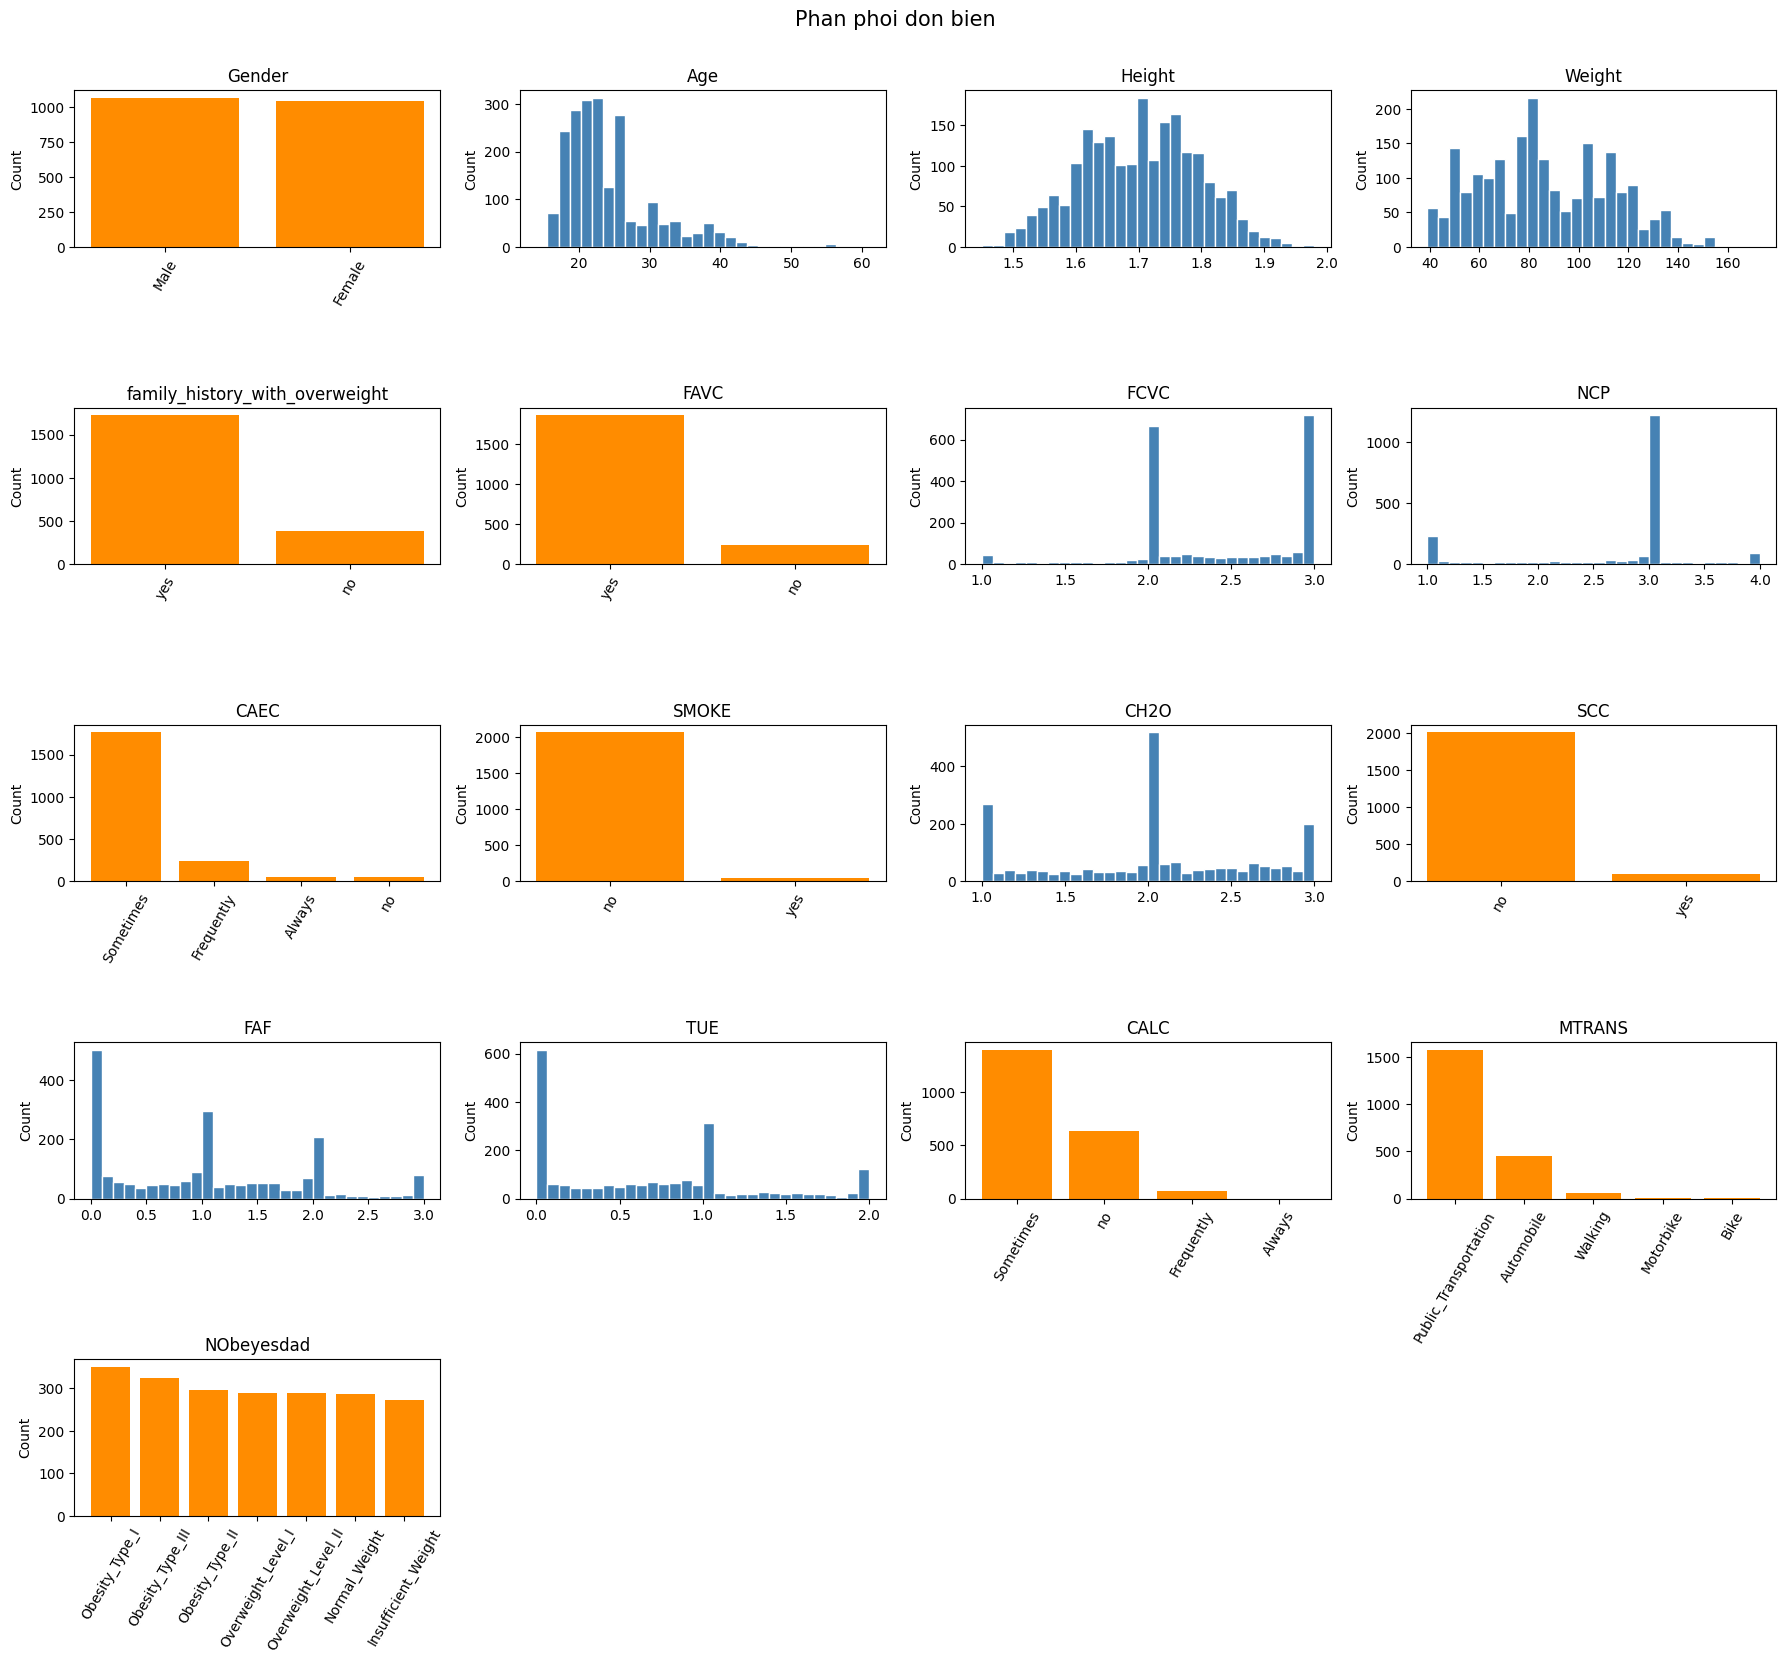

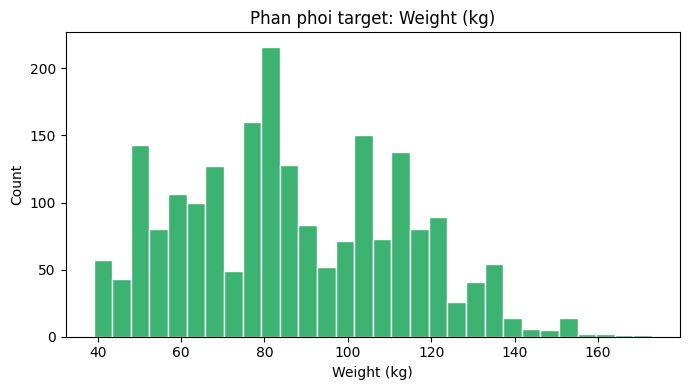

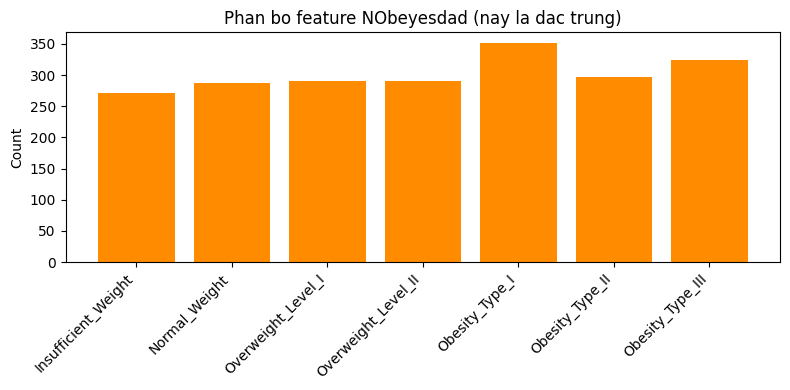

In [4]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
cols = df.columns.tolist()
ncols = 4; nrows = int(np.ceil(len(cols)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.5, nrows*3.3)); axes = axes.flatten()
for i, c in enumerate(cols):
    ax = axes[i]
    if c in num_cols:
        ax.hist(df[c], bins=30, color='steelblue', edgecolor='white')
    else:
        vc = df[c].value_counts()
        ax.bar(vc.index.astype(str), vc.values, color='darkorange'); ax.tick_params(axis='x', rotation=60)
    ax.set_title(c); ax.set_ylabel('Count')
for j in range(len(cols), len(axes)): axes[j].set_visible(False)
plt.suptitle('Phan phoi don bien', fontsize=15, y=1.005); plt.tight_layout(); plt.show()

# --- Luu rieng: phan phoi TARGET Weight (histogram) ---
plt.figure(figsize=(7, 4))
plt.hist(df['Weight'], bins=30, color='mediumseagreen', edgecolor='white')
plt.title('Phan phoi target: Weight (kg)'); plt.xlabel('Weight (kg)'); plt.ylabel('Count')
plt.tight_layout(); plt.savefig(os.path.join(ASSETS_DIR, 'ob_weight_dist.png'), dpi=150, bbox_inches='tight'); plt.show()

# --- Luu rieng: phan bo FEATURE NObeyesdad (bar, theo thu tu muc beo) ---
vc = df['NObeyesdad'].value_counts().reindex(ORDER)
plt.figure(figsize=(8, 4))
plt.bar(range(len(vc)), vc.values, color='darkorange')
plt.xticks(range(len(vc)), vc.index, rotation=45, ha='right')
plt.title('Phan bo feature NObeyesdad (nay la dac trung)'); plt.ylabel('Count')
plt.tight_layout(); plt.savefig(os.path.join(ASSETS_DIR, 'ob_classbalance.png'), dpi=150, bbox_inches='tight'); plt.show()

> 📊 **Phân tích:** Target `Weight` **gần đối xứng** (39–173 kg, mean ≈ 86,9), phù hợp hồi quy. Feature `NObeyesdad`
> **khá cân bằng** (7 mức, mỗi mức ~270–350 mẫu). `Age` lệch phải (đa số 20–30 tuổi); `Height` gần chuẩn. Các cột hành vi
> co cụm ở vài mức (bản chất rời rạc). Biến phân loại **rất mất cân bằng**: `SMOKE` (2043 *no* / 44 *yes*),
> `SCC` (1991/96), `family_history` 1722/365; `CALC` có *Always* cực hiếm; `MTRANS` chủ yếu *Public_Transportation*.

## 3. Cardinality biến phân loại

**Lý do:** Đếm số giá trị duy nhất để chọn cách encode phù hợp.

In [5]:
df[cat_cols].nunique().to_frame('n_unique')

,n_unique
Gender,2
family_history_with_overweight,2
FAVC,2
CAEC,4
SMOKE,2
SCC,2
CALC,4
MTRANS,5
NObeyesdad,7


> 📊 **Phân tích:** Cardinality **thấp** → encode theo quy tắc: **nhị phân** (`Gender`,
> `family_history_with_overweight`, `FAVC`, `SMOKE`, `SCC` — 2 mức) → **binary mapping (0/1)**;
> **thứ bậc** (`CAEC`, `CALC` — `no`<`Sometimes`<`Frequently`<`Always`) → **ordinal**; `NObeyesdad`
> (7 lớp **có thứ tự**) → **ordinal 0..6** (feature); `MTRANS` (5 nhóm, **danh nghĩa thuần**) →
> **one-hot giữ đủ 5 mức (không drop_first)**.

## 4. Outlier & dòng trùng

**Lý do:** Boxplot (1.5·IQR) cho biến số + đếm dòng trùng (bộ gốc có phần tổng hợp).

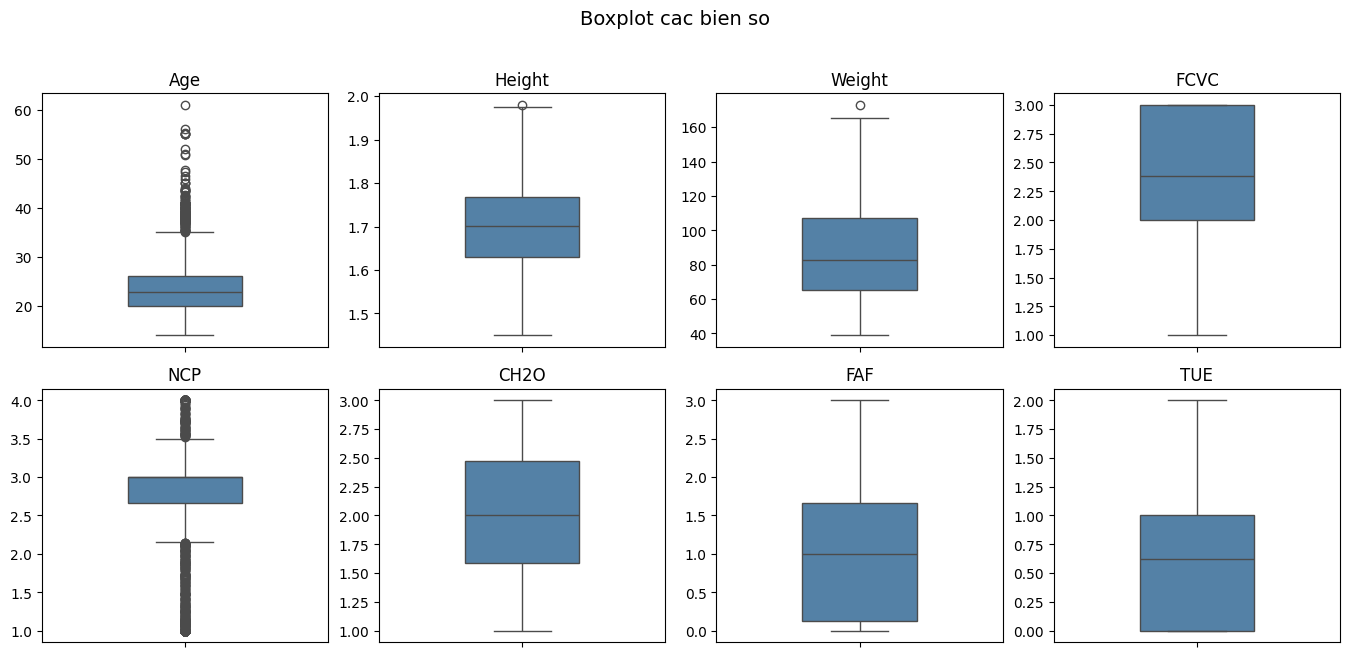

So dong trung lap: 24


In [6]:
n = len(num_cols); ncols = 4; nrows = int(np.ceil(n/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3.4, nrows*3.2)); axes = axes.flatten()
for i, c in enumerate(num_cols):
    sns.boxplot(y=df[c], ax=axes[i], color='steelblue', width=0.4); axes[i].set_title(c); axes[i].set_ylabel('')
for j in range(n, len(axes)): axes[j].set_visible(False)
plt.suptitle('Boxplot cac bien so', fontsize=14, y=1.02); plt.tight_layout(); plt.show()
print('So dong trung lap:', int(df.duplicated().sum()))

> 📊 **Phân tích:** Bản gốc đầy đủ có **24 dòng trùng** (do phần dữ liệu tổng hợp SMOTE) → **loại bỏ** để tránh
> thiên lệch & rò rỉ train–test (còn **2.087**). `Age` có vài outlier trên (tới ~61 tuổi) nhưng **là giá trị thật**,
> không phải lỗi; `Weight`/`Height` trong khoảng người thật. Các cột hành vi bị chặn trong thang cố định nên gần như
> không có outlier → **không cần cắt cực trị/log**, chỉ **bỏ trùng**.

## 5. Quan hệ feature `NObeyesdad` ↔ target `Weight`

**Lý do:** `NObeyesdad` (nay là feature) là nhãn mức béo phì suy ra từ BMI → kỳ vọng tách `Weight`
rất mạnh. Boxplot `Weight` theo từng mức `NObeyesdad` cho thấy quan hệ này (và mức độ leakage khái niệm).

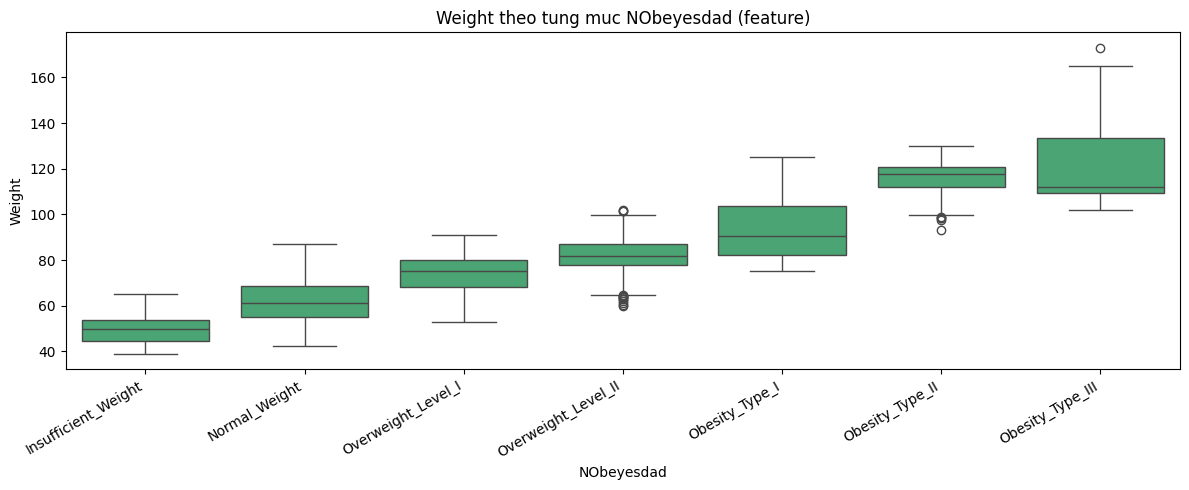

In [7]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='NObeyesdad', y='Weight', order=ORDER, color='mediumseagreen')
plt.xticks(rotation=30, ha='right'); plt.title('Weight theo tung muc NObeyesdad (feature)')
plt.tight_layout(); plt.savefig(os.path.join(ASSETS_DIR, 'ob_weight_by_class.png'), dpi=150, bbox_inches='tight'); plt.show()

> 📊 **Phân tích:** `Weight` **tăng đơn điệu** theo bậc `NObeyesdad` và được tách **rất mạnh** (η ≈ 0,92).
> ⚠️ **Cảnh báo leakage khái niệm:** `NObeyesdad` (và `Height`) gần như **định nghĩa** `Weight` qua BMI —
> mô hình dùng feature này sẽ đạt fit rất cao một cách "dễ dàng"; cần lưu ý khi diễn giải hệ số/độ chính xác.

## 6. Tương quan giữa các biến số (gồm target `Weight`)

**Lý do:** Xem `Weight` tương quan với biến số nào, và phát hiện trùng lặp thông tin giữa các biến số.

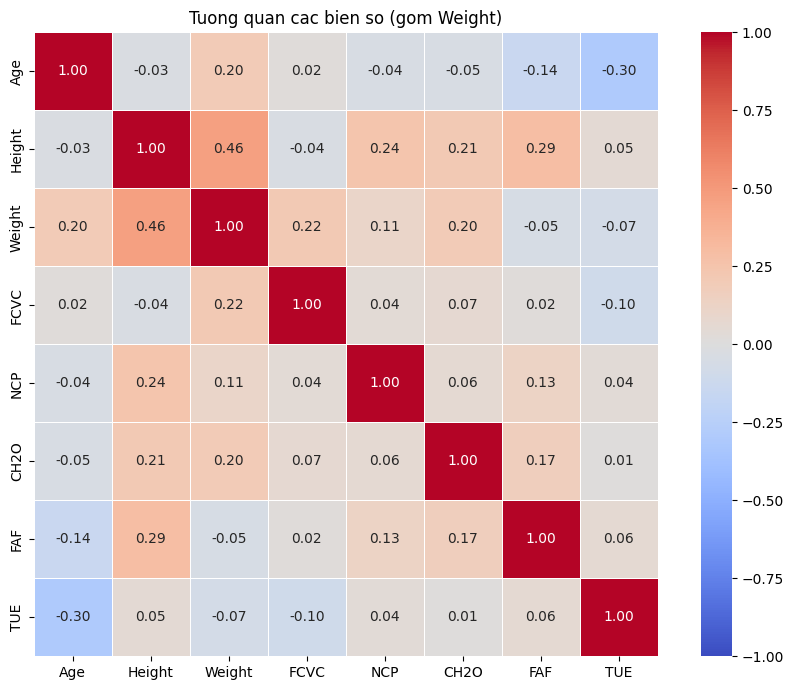

In [8]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title('Tuong quan cac bien so (gom Weight)'); plt.tight_layout()
plt.savefig(os.path.join(ASSETS_DIR, 'ob_corr.png'), dpi=150, bbox_inches='tight'); plt.show()

> 📊 **Phân tích:** `Weight` tương quan dương vừa với `Height`; các biến hành vi (`FCVC`,`FAF`,`TUE`,`NCP`,`CH2O`)
> tương quan **yếu** với nhau và với `Weight` → tín hiệu numeric "thật" cho `Weight` chủ yếu từ `Height`;
> phần còn lại nằm ở các biến phân loại (xem Mục 7).

## 7. Xếp hạng ảnh hưởng lên target `Weight`

**Lý do:** Target nay là **numeric** → đo bằng **|Pearson|** cho feature số và **η (correlation ratio)**
cho feature phân loại (cả hai ∈ [0,1]), để xem feature nào dự đoán `Weight` mạnh nhất.

                       feature  strength                type
                    NObeyesdad     0.921      category (eta)
family_history_with_overweight     0.497      category (eta)
                        Height     0.463 numeric (|Pearson|)
                          CAEC     0.419      category (eta)
                          FAVC     0.272      category (eta)
                          CALC     0.261      category (eta)
                          FCVC     0.216 numeric (|Pearson|)
                           Age     0.203 numeric (|Pearson|)
                           SCC     0.202      category (eta)
                          CH2O     0.201 numeric (|Pearson|)
                        Gender     0.162      category (eta)
                        MTRANS     0.113      category (eta)
                           NCP     0.107 numeric (|Pearson|)
                           TUE     0.072 numeric (|Pearson|)
                           FAF     0.051 numeric (|Pearson|)
                        

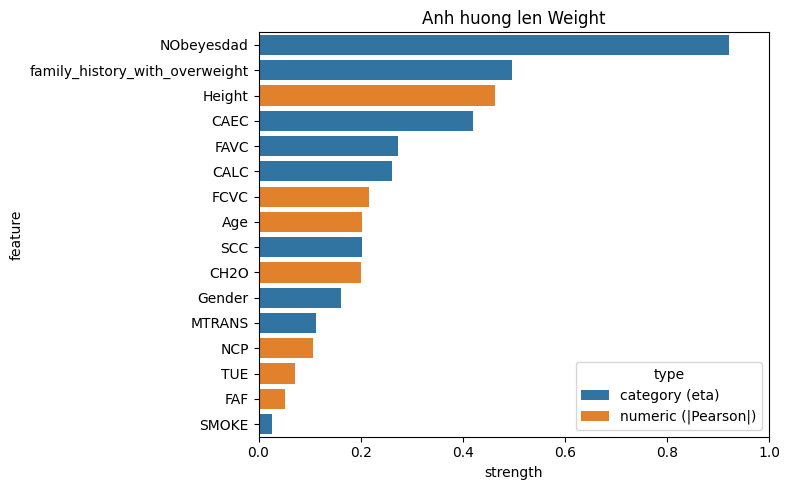

In [9]:
def correlation_ratio(categories, values):
    t = pd.DataFrame({'c': categories, 'v': values}).dropna()
    v = t['v'].values; c = t['c'].values
    sst = ((v - v.mean())**2).sum()
    if sst == 0: return 0.0
    return np.sqrt(sum(len(v[c==k])*(v[c==k].mean()-v.mean())**2 for k in pd.unique(c))/sst)

TARGET = 'Weight'  # bai toan hoi quy: target la numeric
rec = []
# numeric feature  vs numeric target -> |Pearson|
for c in [x for x in num_cols if x != TARGET]:
    rec.append({'feature': c, 'strength': abs(df[c].corr(df[TARGET])), 'type': 'numeric (|Pearson|)'})
# categorical feature vs numeric target -> eta (correlation ratio)
for c in cat_cols:
    rec.append({'feature': c, 'strength': correlation_ratio(df[c], df[TARGET]), 'type': 'category (eta)'})
assoc = pd.DataFrame(rec).sort_values('strength', ascending=False).reset_index(drop=True)
print(assoc.round(3).to_string(index=False))
plt.figure(figsize=(8,5))
sns.barplot(data=assoc, y='feature', x='strength', hue='type', dodge=False)
plt.title('Anh huong len Weight'); plt.xlim(0,1); plt.tight_layout()
plt.savefig(os.path.join(ASSETS_DIR, 'ob_assoc.png'), dpi=150, bbox_inches='tight'); plt.show()

> 📊 **Phân tích:** Mạnh nhất **áp đảo** là **`NObeyesdad`** (η≈0,92) — đúng cảnh báo Mục 5: feature này suy ra
> từ BMI nên gần như định nghĩa `Weight` (**leakage khái niệm**). Nhóm tín hiệu "thật" mạnh kế tiếp:
> `family_history_with_overweight` (η≈0,49), `Height` (|Pearson|≈0,46), `CAEC` (≈0,41), `FAVC` (≈0,27),
> `CALC` (≈0,27), `FCVC` (≈0,22). Yếu nhất: `SMOKE` (≈0,02), `FAF` (≈0,06), `TUE` (≈0,08), `NCP` (≈0,09),
> `MTRANS` (≈0,12); `Gender` cũng khá yếu (≈0,16). → Nếu muốn dự đoán `Weight` "công bằng" từ lối sống, nên cân nhắc
> bỏ `NObeyesdad`/`Height` và dựa vào tiền sử gia đình + thói quen ăn uống.

## 8. Lưu bộ đã làm sạch

**Lý do:** Xuất bộ sạch (đã bỏ trùng), **giữ nguyên** biến phân loại để encode ở Mục 9. Lưu `obesity_processed.csv`.

In [10]:
df_processed = df.drop_duplicates().reset_index(drop=True).copy()
out = os.path.join(DATA_DIR, 'obesity_processed.csv')
df_processed.to_csv(out, index=False)
print('Da luu', out, '|', df_processed.shape, '| missing:', int(df_processed.isna().sum().sum()))
df_processed.head()

Da luu /content/drive/MyDrive/AIO-Conquer02/obesity_processed.csv | (2087, 17) | missing: 0


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 9. Encoding — theo quy tắc loại biến ⭐

**Quy tắc:**
- **Nhị phân** (`Gender`, `family_history_with_overweight`, `FAVC`, `SMOKE`, `SCC`) → **binary mapping** (1 cột 0/1).
  Lý do bỏ one-hot cho biến **2 mức**: one-hot tạo **2 cột** thoả `A + B = 1` → **tương quan = −1 (đa cộng tuyến
  hoàn hảo)**, 1 cột dư thừa làm hệ số Linear/Lasso bất ổn. Ta chứng minh ở ô dưới rồi dùng binary mapping.
- **Thứ bậc** (`CAEC`, `CALC`) → **ordinal** `no=0 < Sometimes=1 < Frequently=2 < Always=3`.
- `NObeyesdad` (7 lớp **có thứ tự**) → **ordinal 0..6** theo mức béo — nay là **feature**.
- **Danh nghĩa thuần** `MTRANS` (5 mức) → **one-hot giữ đủ 5 cột (không `drop_first`)**.
- Target `Weight` giữ nguyên (numeric, không encode).

In [11]:
# Chung minh: one-hot mot bien nhi phan -> 2 cot tuong quan -1
demo = pd.get_dummies(df_processed[['Gender']], columns=['Gender']).astype(int)
print('One-hot Gender tao', demo.shape[1], 'cot:', demo.columns.tolist())
print('Tuong quan giua 2 cot one-hot =', round(demo.corr().iloc[0,1], 3), '(da cong tuyen hoan hao)')
print('--> Binary mapping chi can 1 cot:', "Gender (Male=1, Female=0)")

One-hot Gender tao 2 cot: ['Gender_Female', 'Gender_Male']
Tuong quan giua 2 cot one-hot = -1.0 (da cong tuyen hoan hao)
--> Binary mapping chi can 1 cot: Gender (Male=1, Female=0)


In [12]:
df_encoded = df_processed.copy()

# (1) Nhi phan -> 1 cot 0/1
binary_map = {
    'Gender': {'Female': 0, 'Male': 1},
    'family_history_with_overweight': {'no': 0, 'yes': 1},
    'FAVC': {'no': 0, 'yes': 1},
    'SMOKE': {'no': 0, 'yes': 1},
    'SCC': {'no': 0, 'yes': 1},
}
for col, m in binary_map.items():
    df_encoded[col] = df_encoded[col].map(m).astype(int)

# (2) Thu bac -> ordinal
freq_order = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
for col in ['CAEC', 'CALC']:
    df_encoded[col] = df_encoded[col].map(freq_order).astype(int)

# (3) NObeyesdad (co thu tu) -> ordinal 0..6, nay la FEATURE
df_encoded['NObeyesdad'] = df_encoded['NObeyesdad'].map({k: i for i, k in enumerate(ORDER)}).astype(int)

# (4) Danh nghia thuan MTRANS -> one-hot giu du 5 muc (KHONG drop_first)
df_encoded = pd.get_dummies(df_encoded, columns=['MTRANS'])
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

out = os.path.join(DATA_DIR, 'obesity_encoded.csv')
df_encoded.to_csv(out, index=False)
print('Da luu', out, '|', df_encoded.shape)
print('Target = Weight (numeric). So feature =', df_encoded.shape[1] - 1)
print('Cot:', df_encoded.columns.tolist())
df_encoded.head()

Da luu /content/drive/MyDrive/AIO-Conquer02/obesity_encoded.csv | (2087, 21)
Target = Weight (numeric). So feature = 20
Cot: ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'NObeyesdad', 'MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,SCC,FAF,TUE,CALC,NObeyesdad,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0,21.0,1.62,64.0,1,0,2.0,3.0,1,0,...,0,0.0,1.0,0,1,0,0,0,1,0
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1,1,...,1,3.0,0.0,1,1,0,0,0,1,0
2,1,23.0,1.80,77.0,1,0,2.0,3.0,1,0,...,0,2.0,1.0,2,1,0,0,0,1,0
3,1,27.0,1.80,87.0,0,0,3.0,3.0,1,0,...,0,2.0,0.0,2,2,0,0,0,0,1
4,1,22.0,1.78,89.8,0,0,2.0,1.0,1,0,...,0,0.0,0.0,1,3,0,0,0,1,0


> 💾 **Kết quả:** `obesity_encoded.csv` — **2.087 dòng × 21 cột** (20 feature + target `Weight`):
> 5 biến nhị phân → **5 cột 0/1**; `CAEC`/`CALC` → **2 cột ordinal**; `NObeyesdad` → **1 cột ordinal 0..6** (feature);
> `MTRANS` → **5 cột one-hot** (giữ đủ mức). Toàn bộ là **số**, không còn cặp cột đa cộng tuyến hoàn hảo từ biến nhị phân.
>
> **Kiểm tra collinearity (ô trên):** một biến nhị phân one-hot có corr = **−1.000** giữa 2 cột; binary mapping triệt tiêu hẳn.